# SWIM distance and logical gap: saved-data comparison

Load a completed canonical YAML run and compare saved SWIM distance and complementary logical gap. Each plotted series uses its own decoder's `logical_error.parquet`; the comparison does not assume that different decoder points share sampled shots. The SWIM score is the minimum original-prior stage-2 distance among candidates in the selected logical class. Supported SWIM points are one-round triangular data-only bit-flip memory and validated closed triangular `rounds=d` Z-memory.

The three views follow the scatter conventions of `circuit_level_swim_selection_strategies.ipynb`: outcome frequencies, conditional logical error probability, and post-selection with 99% Wilson bands. No fitted calibration curve is overlaid.


In [1]:
from pathlib import Path
import importlib
import matplotlib.pyplot as plt
from IPython.display import display
import color_code_softoutput.analysis.workflow_soft_output as workflow_soft_output
importlib.reload(workflow_soft_output)
WorkflowSoftOutputRun = workflow_soft_output.WorkflowSoftOutputRun

# Resolve data paths from the repository root, even when the kernel starts
# in notebooks/.
PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

run_directory = PROJECT_ROOT / "cluster_results/26_09_28_00_17_00_00df6314"
run = WorkflowSoftOutputRun(run_directory)
run.run.catalog


,decoder_type,circuit_type,distance,rounds,physical_error_rate,noise_model,cnot_schedule,expected_shots,point_directory,data_available
0,concat_mwpm,tri,5,1,0.01,bitflip,tri_optimal,1000000,"decoder_type=concat_mwpm,circuit_type=tri,d=5,...",True
1,concat_mwpm_stage2_base,tri,5,1,0.01,bitflip,tri_optimal,1000000,"decoder_type=concat_mwpm_stage2_base,circuit_t...",True
2,color_correlated,tri,5,1,0.01,bitflip,tri_optimal,1000000,"decoder_type=color_correlated,circuit_type=tri...",True
3,perturbation,tri,5,1,0.01,bitflip,tri_optimal,1000000,"decoder_type=perturbation,circuit_type=tri,d=5...",True
4,tesseract,tri,5,1,0.01,bitflip,tri_optimal,1000000,"decoder_type=tesseract,circuit_type=tri,d=5,r=...",True
...,...,...,...,...,...,...,...,...,...,...
145,concat_mwpm,tri,13,1,0.04,bitflip,tri_optimal,1000000,"decoder_type=concat_mwpm,circuit_type=tri,d=13...",True
146,concat_mwpm_stage2_base,tri,13,1,0.04,bitflip,tri_optimal,1000000,"decoder_type=concat_mwpm_stage2_base,circuit_t...",True
147,color_correlated,tri,13,1,0.04,bitflip,tri_optimal,1000000,"decoder_type=color_correlated,circuit_type=tri...",True
148,perturbation,tri,13,1,0.04,bitflip,tri_optimal,1000000,"decoder_type=perturbation,circuit_type=tri,d=1...",True


## Choose conditions, metrics and grouping

`filters` selects experiment points. `groups` creates separate plotted series; metrics are always separate, even if omitted from `groups`. With distance and physical error rate fixed, `groups=["decoder_type"]` gives one series per decoder and saved metric. Multiple distances/error rates are pooled unless you also group by those fields. A one-field tuple needs a comma: `("decoder_type",)`; a list is easier to edit.

`metrics=["swim_distance", "logical_gap"]` overlays both scores. It reads only the saved combinations: in this run `concat_mwpm` supplies logical gap, while `concat_mwpm_stage2_base` and `color_correlated` supply SWIM. The stage-2-base decoder uses a different final-selection weight from `concat_mwpm`. Every selected point must have at least one requested metric, and every requested metric must occur in the selection. `available_metrics` below shows which files exist.

`bins="auto"` preserves discrete scores when there are few distinct values; an integer such as 40 uses common histogram intervals across series. `round_digits` optionally rounds scores before grouping and post-selection ties. Distribution normalization divides each outcome count by all shots in its own series. `signed_logical_errors` affects only distribution display; selection and conditional rates use the original nonnegative scores.


In [11]:
filters = {
    "physical_error_rate": [0.03],
    "decoder_type": ["concat_mwpm", "perturbation"],
}
groups = ["distance", "decoder_type"]
metrics = ["swim_distance", "logical_gap"]
bins = "auto"  # or 40 for shared histogram intervals
round_digits = 2
signed_logical_errors = False  # True: negate error scores in the distribution
normalize_frequency = False  # True: outcome counts / all shots in each series
yscale = "log"  # zero conditional/post-selection rates show Wilson shading only
run.available_metrics(filters)


,decoder_type,circuit_type,distance,rounds,physical_error_rate,noise_model,cnot_schedule,expected_shots,point_directory,data_available,swim_distance_available,logical_gap_available
0,concat_mwpm,tri,5,1,0.03,bitflip,tri_optimal,1000000,"decoder_type=concat_mwpm,circuit_type=tri,d=5,...",True,False,True
1,perturbation,tri,5,1,0.03,bitflip,tri_optimal,1000000,"decoder_type=perturbation,circuit_type=tri,d=5...",True,True,False
2,concat_mwpm,tri,7,1,0.03,bitflip,tri_optimal,1000000,"decoder_type=concat_mwpm,circuit_type=tri,d=7,...",True,False,True
3,perturbation,tri,7,1,0.03,bitflip,tri_optimal,1000000,"decoder_type=perturbation,circuit_type=tri,d=7...",True,True,False
4,concat_mwpm,tri,9,1,0.03,bitflip,tri_optimal,1000000,"decoder_type=concat_mwpm,circuit_type=tri,d=9,...",True,False,True
5,perturbation,tri,9,1,0.03,bitflip,tri_optimal,1000000,"decoder_type=perturbation,circuit_type=tri,d=9...",True,True,False
6,concat_mwpm,tri,11,1,0.03,bitflip,tri_optimal,1000000,"decoder_type=concat_mwpm,circuit_type=tri,d=11...",True,False,True
7,perturbation,tri,11,1,0.03,bitflip,tri_optimal,1000000,"decoder_type=perturbation,circuit_type=tri,d=1...",True,True,False
8,concat_mwpm,tri,13,1,0.03,bitflip,tri_optimal,1000000,"decoder_type=concat_mwpm,circuit_type=tri,d=13...",True,False,True
9,perturbation,tri,13,1,0.03,bitflip,tri_optimal,1000000,"decoder_type=perturbation,circuit_type=tri,d=1...",True,True,False


## Distribution

Successes use `o`, logical errors use `x`. Points show counts or normalized frequencies at grouped score values. Error scores can be negated for display without modifying saved data.


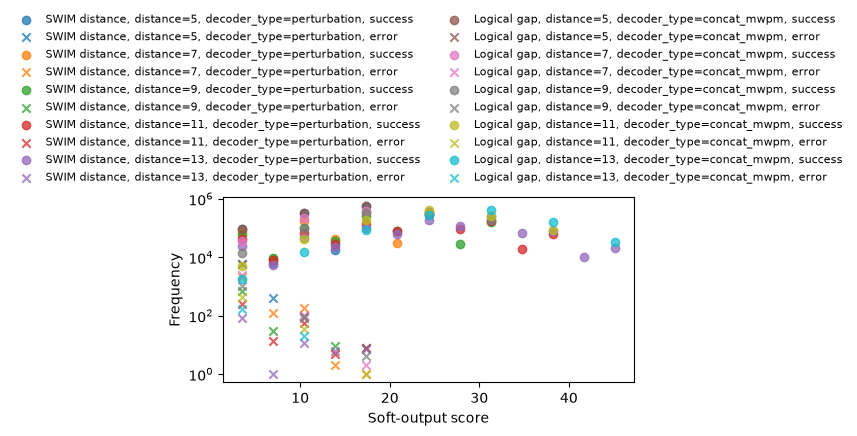

,score,raw_score,logical_error,count,shots,failures,frequency,density,total_shots,bin_left,bin_right,distance,decoder_type,metric
0,3.48,3.48,False,95105,95105,0,95105,95105,1000000,3.48,3.48,5,perturbation,swim_distance
1,6.95,6.95,False,6565,6565,0,6565,6565,1000000,6.95,6.95,5,perturbation,swim_distance
2,10.43,10.43,False,314315,314315,0,314315,314315,1000000,10.43,10.43,5,perturbation,swim_distance
3,13.90,13.90,False,17412,17412,0,17412,17412,1000000,13.90,13.90,5,perturbation,swim_distance
4,17.38,17.38,False,560236,560236,0,560236,560236,1000000,17.38,17.38,5,perturbation,swim_distance


In [12]:
fig_distribution, distribution_table = run.plot_distribution(
    metrics=metrics, filter=filters, group_by=groups, bins=bins,
    signed_logical_errors=signed_logical_errors,
    normalize_frequency=normalize_frequency, round_digits=round_digits,
    yscale=yscale,
)
display(fig_distribution)
plt.close(fig_distribution)
distribution_table.head()


## Conditional logical error probability

The empirical probability in each score group is failures / shots. The shade is its 99% Wilson interval. Colors identify metric/decoder series; SWIM uses diamonds and logical gap uses squares. Zero-rate groups retain the band but have no plotted estimate.


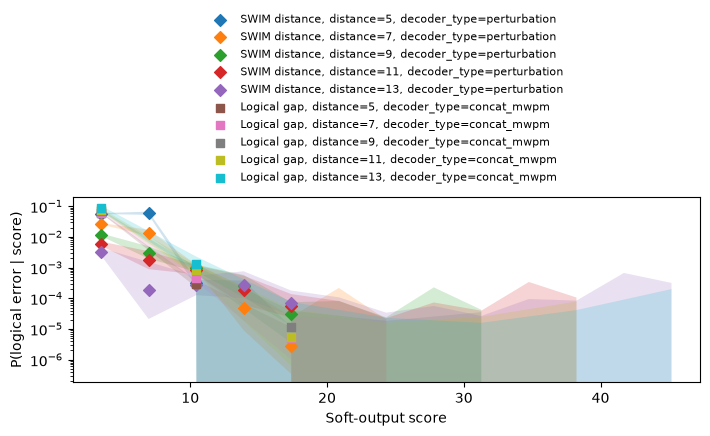

,score,shots,failures,logical_error_rate,low,high,distance,decoder_type,metric
0,3.48,100959,5854,0.057984,0.056118,0.059908,5,perturbation,swim_distance
1,6.95,6980,415,0.059456,0.052575,0.067173,5,perturbation,swim_distance
2,10.43,314413,98,0.000312,0.000240,0.000404,5,perturbation,swim_distance
3,13.90,17412,0,0.000000,0.000000,0.000381,5,perturbation,swim_distance
4,17.38,560236,0,0.000000,0.000000,0.000012,5,perturbation,swim_distance


In [13]:
fig_conditional, conditional_table = run.plot_conditional_ler(
    metrics=metrics, filter=filters, group_by=groups, bins=bins,
    round_digits=round_digits, yscale=yscale,
)
display(fig_conditional)
plt.close(fig_conditional)
conditional_table.head()


## Post-selection

Retain scores >= each threshold and reject lower scores. Each exact threshold gives a scatter point: rejected fraction versus the logical error rate among retained shots. The shade is a 99% Wilson interval on the retained rate, not an interval on the rejected fraction. Zero retained-error rates show only the band. Error-score negation is never used here.


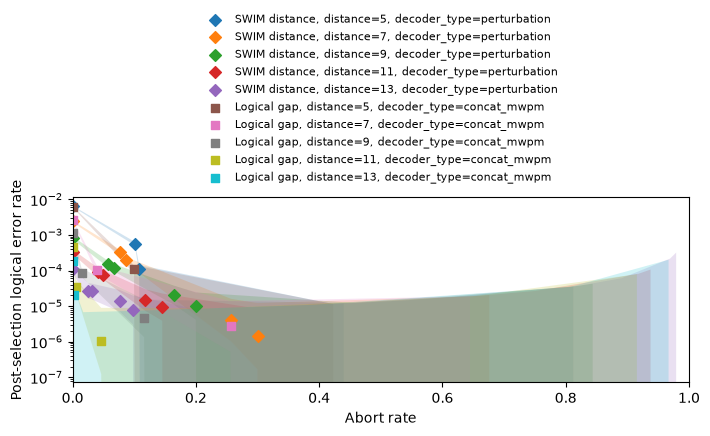

,threshold,abort_rate,retained_shots,retained_failures,residual_logical_error_rate,low,high,distance,decoder_type,metric
0,3.48,0.000000,1000000,6367,0.006367,0.006165,0.006575,5,perturbation,swim_distance
1,6.95,0.100959,899041,513,0.000571,0.000509,0.000639,5,perturbation,swim_distance
2,10.43,0.107939,892061,98,0.000110,0.000085,0.000142,5,perturbation,swim_distance
3,13.90,0.422352,577648,0,0.000000,0.000000,0.000011,5,perturbation,swim_distance
4,17.38,0.439764,560236,0,0.000000,0.000000,0.000012,5,perturbation,swim_distance


In [14]:
fig_postselection, postselection_table = run.plot_postselection(
    metrics=metrics, filter=filters, group_by=groups,
    round_digits=round_digits, yscale=yscale,
)
display(fig_postselection)
plt.close(fig_postselection)
postselection_table.head()


In [6]:
stem = "_vs_".join(metrics)
for name, figure in {
    "distribution": fig_distribution,
    "conditional_ler": fig_conditional,
    "postselection": fig_postselection,
}.items():
    for extension in ("png", "pdf"):
        figure.savefig(run_directory / f"{stem}_{name}.{extension}", dpi=180, bbox_inches="tight")
